In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [17]:
titanic = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

# handle missing data

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(
    titanic[["embarked"]]
)

# encode

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(
    titanic["embarked"]
)

X = titanic[features]
y = titanic["survived"]

In [18]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [27]:
# Decision Tree

model = DecisionTreeClassifier(max_depth=4)

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print(
    "Training accuracy: ",
    accuracy_score(y_train, y_pred_train) * 100,
    "%"
)

print(
    "Testing accuracy: ",
    accuracy_score(y_test, y_pred_test) * 100,
    "%"
)

Training accuracy:  84.75120385232745 %
Testing accuracy:  82.46268656716418 %


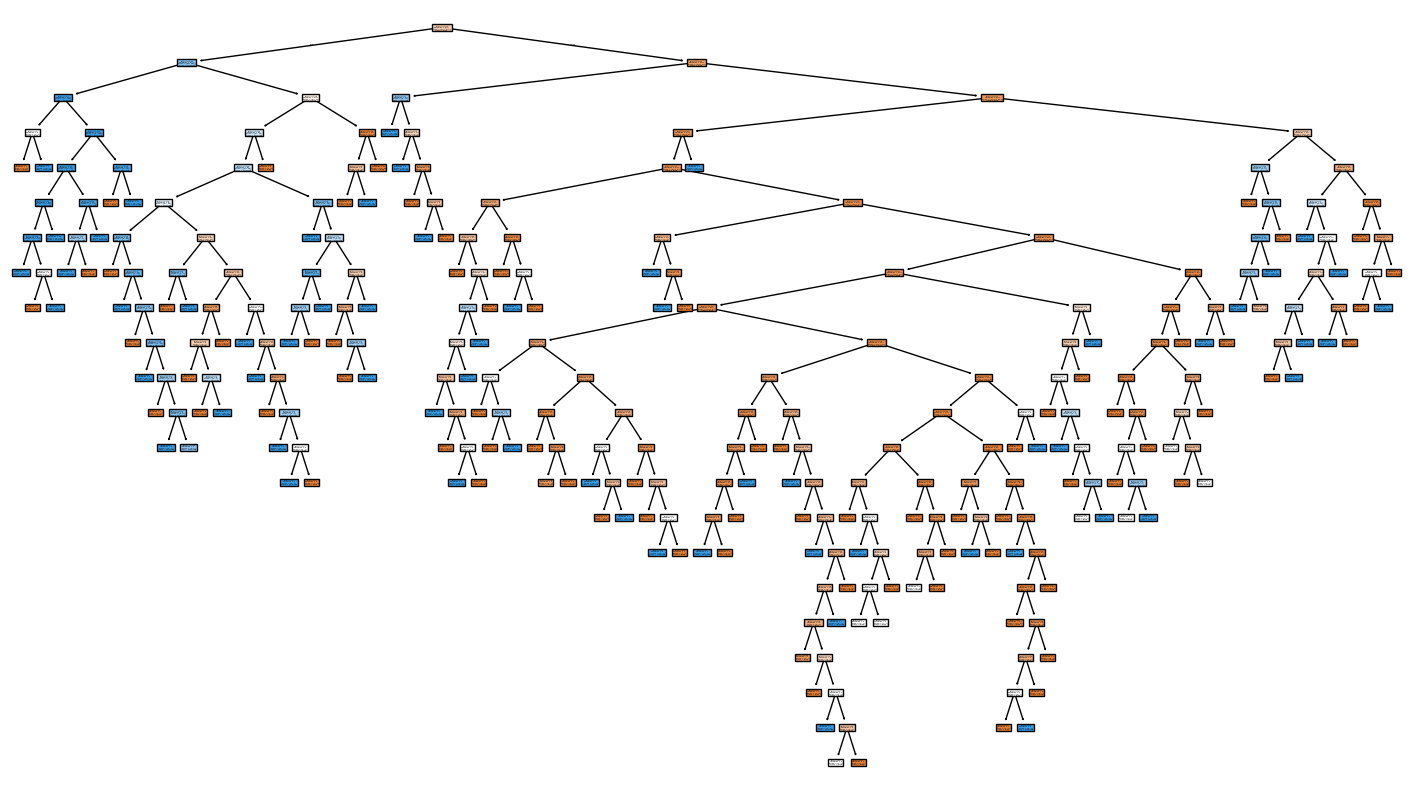

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)

plt.show()

# Random Forest to overcome overfitting

In [28]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=401,
    oob_score=True,
    max_depth=4
      
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Testing Accuracy : ", accuracy_score(y_test, y_pred) * 100)
print("OOB Score : ", rf.oob_score_ * 100)

Testing Accuracy :  81.71641791044776
OOB Score :  82.8250401284109


In [29]:
# Bagging Classifier
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)
y_pred = bagging.predict(X_test)

print("Testing Accuracy : ", accuracy_score(y_test, y_pred) * 100)


Testing Accuracy :  77.61194029850746


In [30]:
# Bagging Classifier for Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    estimator=base_model,
    n_estimators=201
)

bagging.fit(X_train, y_train)

y_pred = bagging.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.7947761194029851
